# Análisis preliminar corregido del dataset STARSS23/DCASE 2024

Notebook corregido para analizar:

1. Distribución de eventos por clase.
2. Distribución de distancias.
3. Distribución espacial X-Y reconstruida usando azimut, elevación y distancia.
4. Nivel de polifonía.

**Corrección principal:** en el formato DCASE 2024 / STARSS23 con distancia los metadatos se interpretan como:

`frame, class, track, azimuth, elevation, distance_cm`

Por tanto:

- la columna 3 es el **azimut** en grados;
- la columna 4 es la **elevación** en grados;
- la columna 5 es la **distancia en centímetros**, que debe convertirse a metros dividiendo entre 100.

El mapa X-Y corregido se calcula convirtiendo coordenadas esféricas a cartesianas mediante azimut, elevación y distancia en metros.


In [6]:

# ============================================================
# 0. CONFIGURACIÓN GENERAL
# ============================================================

import os
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# ------------------------------------------------------------
# RUTA DE METADATOS
# Cambia esta ruta si tienes el dataset en otra carpeta.
# ------------------------------------------------------------
metadata_dir = r"E:/Uni/TFG/dataset/metadata_dev"

# Carpeta donde se guardarán las figuras.
# "." significa la misma carpeta desde la que ejecutes el notebook.
output_dir = "."
Path(output_dir).mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# FORMATO DE METADATOS
# Para DCASE 2024 / STARSS23 con distancia, el formato usado aquí es:
# [frame, class, track, azimuth, elevation, distance_cm]
# IMPORTANTE: la distancia de la columna 5 está en centímetros y se convierte a metros.
# ------------------------------------------------------------
METADATA_FORMAT = "dcase_2024_spherical_6"

# Si algún CSV tuviera coordenadas cartesianas en cm en columnas 3,4,5,
# podrías cambiarlo manualmente a:
# METADATA_FORMAT = "cartesian_cm_6"
#
# Si tuviera coordenadas cartesianas en metros:
# METADATA_FORMAT = "cartesian_m_6"

CLASS_NAMES = {
    0: "Female speech, woman speaking",
    1: "Male speech, man speaking",
    2: "Clapping",
    3: "Telephone",
    4: "Laughter",
    5: "Domestic sounds",
    6: "Walk, footsteps",
    7: "Door, open or close",
    8: "Music",
    9: "Musical instrument",
    10: "Water tap, faucet",
    11: "Bell",
    12: "Knock",
}

CLASS_DESCRIPTIONS = {
    0: "Voz femenina o habla de mujer.",
    1: "Voz masculina o habla de hombre.",
    2: "Sonidos de aplausos.",
    3: "Timbres de teléfono tradicionales y tonos de llamada no musicales.",
    4: "Risa.",
    5: "Sonidos domésticos, como aspiradora, hervidor de agua o ventilador mecánico.",
    6: "Pasos o sonidos asociados a caminar.",
    7: "Apertura o cierre de puertas y armarios.",
    8: "Música de fondo o música pop reproducida por un altavoz en la sala.",
    9: "Instrumentos musicales como guitarra acústica, marimba, xilófono, cencerro, piano o sonajero.",
    10: "Sonido de grifo o agua corriente.",
    11: "Sonidos de campana, timbres o campanadas simples.",
    12: "Golpes o llamadas a una puerta o superficie.",
}

def list_metadata_csvs(metadata_dir):
    """Devuelve la lista recursiva de CSVs de metadatos."""
    metadata_path = Path(metadata_dir)
    if not metadata_path.exists():
        raise FileNotFoundError(f"La ruta de metadatos no existe: {metadata_dir}")
    return sorted(metadata_path.rglob("*.csv"))

def read_metadata_csv(path):
    """Lee un CSV de metadatos sin cabecera y convierte columnas numéricas."""
    df = pd.read_csv(path, header=None)
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    return df.dropna(how="all")

def print_format_diagnostic(csv_files, n_files=1):
    """Muestra diagnóstico rápido para comprobar el formato real de los CSV."""
    print("Ruta de metadatos:", metadata_dir)
    print("CSVs encontrados:", len(csv_files))
    print("Formato asumido:", METADATA_FORMAT)

    for path in csv_files[:n_files]:
        df = read_metadata_csv(path)
        print("\n--- DIAGNÓSTICO DE FORMATO ---")
        print("Archivo:", path.name)
        print("Número de columnas:", df.shape[1])
        print("Primeras filas:")
        display(df.head())

        cols = [c for c in [3, 4, 5] if c in df.columns]
        if cols:
            print("Estadísticos columnas 3, 4, 5 si existen:")
            display(df[cols].describe())

        if df.shape[1] >= 6 and METADATA_FORMAT == "dcase_2024_spherical_6":
            print("\nInterpretación esperada para DCASE 2024:")
            print("  columna 3 -> azimut (grados)")
            print("  columna 4 -> elevación (grados)")
            print("  columna 5 -> distancia (centímetros)")
            dist_m = df.iloc[:, 5].astype(float) / 100.0
            print("\nResumen columna 5 convertida a metros:")
            display(dist_m.describe().to_frame(name="distancia_m"))

        print("------------------------------")

def spherical_to_cartesian(azimuth_deg, elevation_deg, distance_m):
    """
    Convierte azimut, elevación y distancia a coordenadas cartesianas.

    Convención usada:
    x = d * cos(elev) * cos(azim)
    y = d * cos(elev) * sin(azim)
    z = d * sin(elev)

    El objetivo del EDA es obtener una proyección X-Y coherente en metros,
    no fijar una convención física absoluta de orientación de sala.
    """
    az = np.deg2rad(azimuth_deg.astype(float))
    el = np.deg2rad(elevation_deg.astype(float))
    d = distance_m.astype(float)

    x = d * np.cos(el) * np.cos(az)
    y = d * np.cos(el) * np.sin(az)
    z = d * np.sin(el)
    return x, y, z

def extract_spatial_from_df(df):
    """
    Extrae x, y, z, azimuth, elevation y distance de un dataframe de metadatos.

    Por defecto se usa formato DCASE 2024:
    [frame, class, track, azimuth, elevation, distance_cm],
    convirtiendo la distancia de centímetros a metros.
    """
    if df.empty or df.shape[1] < 6:
        return None

    if METADATA_FORMAT == "dcase_2024_spherical_6":
        azimuth = df.iloc[:, 3].astype(float)
        elevation = df.iloc[:, 4].astype(float)
        # En los metadatos DCASE 2024 la distancia está en centímetros.
        # Se convierte a metros para que las figuras y estadísticas sean interpretables.
        distance_cm = df.iloc[:, 5].astype(float)
        distance_m = distance_cm / 100.0

        # Nos quedamos con distancias válidas y positivas.
        valid = distance_m.notna() & (distance_m >= 0) & azimuth.notna() & elevation.notna()
        azimuth = azimuth[valid]
        elevation = elevation[valid]
        distance_m = distance_m[valid]

        x, y, z = spherical_to_cartesian(azimuth, elevation, distance_m)
        return x, y, z, azimuth, elevation, distance_m

    elif METADATA_FORMAT == "cartesian_cm_6":
        x_cm = df.iloc[:, 3].astype(float)
        y_cm = df.iloc[:, 4].astype(float)
        z_cm = df.iloc[:, 5].astype(float)

        valid = x_cm.notna() & y_cm.notna() & z_cm.notna()
        x = x_cm[valid] / 100.0
        y = y_cm[valid] / 100.0
        z = z_cm[valid] / 100.0
        distance = np.sqrt(x**2 + y**2 + z**2)
        azimuth = np.rad2deg(np.arctan2(y, x))
        elevation = np.rad2deg(np.arctan2(z, np.sqrt(x**2 + y**2)))
        return x, y, z, azimuth, elevation, distance

    elif METADATA_FORMAT == "cartesian_m_6":
        x = df.iloc[:, 3].astype(float)
        y = df.iloc[:, 4].astype(float)
        z = df.iloc[:, 5].astype(float)

        valid = x.notna() & y.notna() & z.notna()
        x = x[valid]
        y = y[valid]
        z = z[valid]
        distance = np.sqrt(x**2 + y**2 + z**2)
        azimuth = np.rad2deg(np.arctan2(y, x))
        elevation = np.rad2deg(np.arctan2(z, np.sqrt(x**2 + y**2)))
        return x, y, z, azimuth, elevation, distance

    else:
        raise ValueError(f"Formato no reconocido: {METADATA_FORMAT}")

csv_files = list_metadata_csvs(metadata_dir)
print_format_diagnostic(csv_files)


Ruta de metadatos: E:/Uni/TFG/dataset/metadata_dev
CSVs encontrados: 168
Formato asumido: dcase_2024_spherical_6

--- DIAGNÓSTICO DE FORMATO ---
Archivo: fold4_room23_mix001.csv
Número de columnas: 6
Primeras filas:


,0,1,2,3,4,5
0,1,8,0,14,0,392
1,1,5,0,-37,-18,205
2,2,8,0,14,0,392
3,2,1,1,-88,2,66
4,2,5,0,-37,-18,205


Estadísticos columnas 3, 4, 5 si existen:


,3,4,5
count,1846.000000,1846.000000,1846.000000
mean,-7.853196,-9.638137,295.280607
std,23.921974,7.978775,81.493487
min,-88.000000,-58.000000,61.000000
25%,-37.000000,-18.000000,205.000000
50%,12.500000,-11.000000,269.500000
75%,14.000000,0.000000,392.000000
max,26.000000,4.000000,392.000000



Interpretación esperada para DCASE 2024:
  columna 3 -> azimut (grados)
  columna 4 -> elevación (grados)
  columna 5 -> distancia (centímetros)

Resumen columna 5 convertida a metros:


,distancia_m
count,1846.000000
mean,2.952806
std,0.814935
min,0.610000
25%,2.050000
50%,2.695000
75%,3.920000
max,3.920000


------------------------------


Calculando distribución de eventos por clase...
Total de CSVs procesados: 168

--- Distribución de clases ---


,ID,Clase,Frames_activos,Porcentaje,Archivos_con_clase
0,0,"Female speech, woman speaking",71482,21.193855,97
1,1,"Male speech, man speaking",89489,26.532791,144
2,2,Clapping,1554,0.460749,28
3,3,Telephone,2428,0.719883,33
4,4,Laughter,9404,2.788213,114
5,5,Domestic sounds,44887,13.308645,46
6,6,"Walk, footsteps",7948,2.356520,75
7,7,"Door, open or close",1611,0.477649,45
8,8,Music,71361,21.157980,54
9,9,Musical instrument,30770,9.123065,19


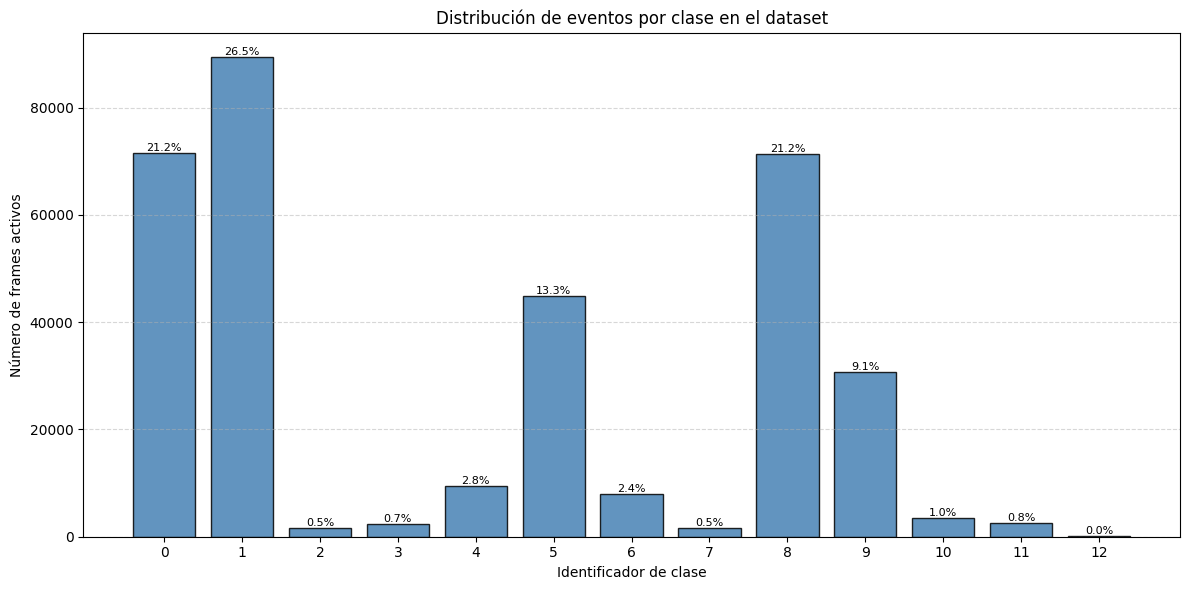

In [7]:

# ============================================================
# 1. DISTRIBUCIÓN DE EVENTOS POR CLASE
# ============================================================

print("Calculando distribución de eventos por clase...")

class_counter = Counter()
file_counter = defaultdict(set)
total_csv_procesados = 0

for path in csv_files:
    try:
        df = read_metadata_csv(path)
        if df.empty or df.shape[1] < 2:
            continue

        total_csv_procesados += 1
        class_col = df.iloc[:, 1].dropna().astype(int)

        for cls in class_col:
            class_counter[int(cls)] += 1
            file_counter[int(cls)].add(path.name)

    except Exception as e:
        print(f"Error leyendo {path.name}: {e}")

print(f"Total de CSVs procesados: {total_csv_procesados}")

if not class_counter:
    raise RuntimeError("No se han podido extraer clases. Revisa el formato de los metadatos.")

rows = []
total_frames_activos = sum(class_counter.values())

for cls in sorted(class_counter.keys()):
    count = class_counter[cls]
    rows.append({
        "ID": cls,
        "Clase": CLASS_NAMES.get(cls, f"Clase {cls}"),
        "Frames_activos": count,
        "Porcentaje": 100 * count / total_frames_activos,
        "Archivos_con_clase": len(file_counter[cls]),
    })

class_df = pd.DataFrame(rows)

print("\n--- Distribución de clases ---")
display(class_df)

class_df.to_csv(Path(output_dir) / "resumen_distribucion_clases.csv", index=False, encoding="utf-8-sig")

# Tabla de clases objetivo para la memoria
class_table = pd.DataFrame([
    {
        "Identificador": cls,
        "Clase": CLASS_NAMES[cls],
        "Descripción": CLASS_DESCRIPTIONS[cls],
    }
    for cls in sorted(CLASS_NAMES.keys())
])
class_table.to_csv(Path(output_dir) / "tabla_clases_objetivo.csv", index=False, encoding="utf-8-sig")

# Gráfica
plt.figure(figsize=(12, 6))
bars = plt.bar(
    class_df["ID"].astype(str),
    class_df["Frames_activos"],
    color="steelblue",
    edgecolor="black",
    alpha=0.85
)

plt.title("Distribución de eventos por clase en el dataset")
plt.xlabel("Identificador de clase")
plt.ylabel("Número de frames activos")
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Añadir porcentajes encima de las barras
for bar, pct in zip(bars, class_df["Porcentaje"]):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{pct:.1f}%",
        ha="center",
        va="bottom",
        fontsize=8,
        rotation=0
    )

plt.tight_layout()
plt.savefig(Path(output_dir) / "distribucion_clases_tfg.png", dpi=300)
plt.show()


Extrayendo distancias reales de los metadatos y convirtiendo cm -> m...
Total de frames con distancia válida analizados: 337277

--- Estadísticas de distancia ---


,num_frames,min_m,p25_m,media_m,mediana_m,p75_m,max_m
0,337277,0.25,1.4,1.898129,1.8,2.25,7.02


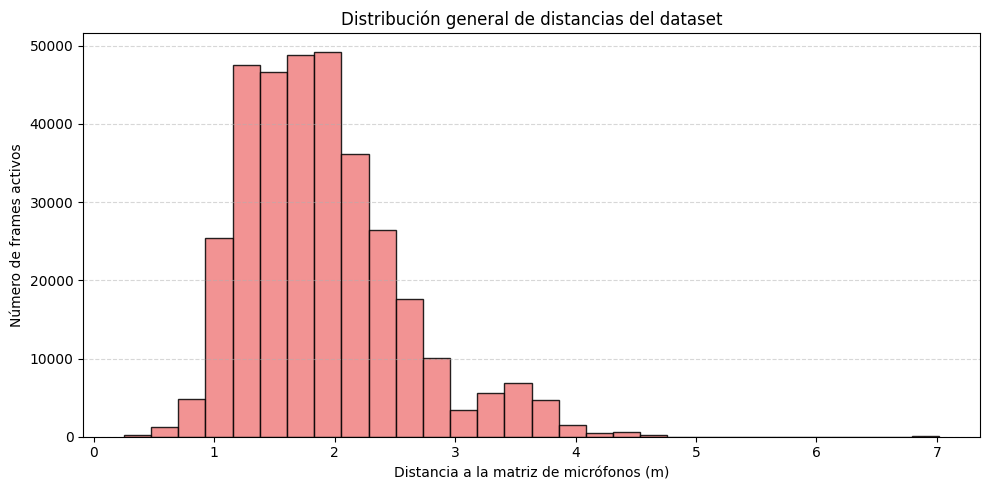

In [8]:

# ============================================================
# 2. DISTRIBUCIÓN DE DISTANCIAS
# ============================================================

print("Extrayendo distancias reales de los metadatos y convirtiendo cm -> m...")

distances = []

for path in csv_files:
    try:
        df = read_metadata_csv(path)
        parsed = extract_spatial_from_df(df)
        if parsed is None:
            continue

        _, _, _, _, _, distance = parsed
        distances.extend(pd.Series(distance).dropna().astype(float).tolist())

    except Exception as e:
        print(f"Error procesando distancias en {path.name}: {e}")

distances = np.array(distances, dtype=float)
distances = distances[np.isfinite(distances)]
distances = distances[distances >= 0]

print(f"Total de frames con distancia válida analizados: {len(distances)}")

if len(distances) == 0:
    raise RuntimeError("No se han extraído distancias. Revisa METADATA_FORMAT y los CSV.")

dist_stats = pd.DataFrame([{
    "num_frames": len(distances),
    "min_m": np.min(distances),
    "p25_m": np.percentile(distances, 25),
    "media_m": np.mean(distances),
    "mediana_m": np.median(distances),
    "p75_m": np.percentile(distances, 75),
    "max_m": np.max(distances),
}])

print("\n--- Estadísticas de distancia ---")
display(dist_stats)
dist_stats.to_csv(Path(output_dir) / "resumen_distancias.csv", index=False, encoding="utf-8-sig")

plt.figure(figsize=(10, 5))
plt.hist(distances, bins=30, color="lightcoral", edgecolor="black", alpha=0.85)
plt.title("Distribución general de distancias del dataset")
plt.xlabel("Distancia a la matriz de micrófonos (m)")
plt.ylabel("Número de frames activos")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()

plt.savefig(Path(output_dir) / "analisis_preliminar_distancias.png", dpi=300)
plt.show()


Calculando coordenadas X-Y reales a partir de azimut, elevación y distancia...
Total de puntos espaciales analizados: 337277

--- Comprobación de coordenadas ---


,distancia_original_media_m,distancia_reconstruida_media_m,error_abs_medio_m,x_min_m,x_max_m,y_min_m,y_max_m
0,1.898129,1.898129,1.021194e-16,-7.0029,4.62591,-3.759458,3.4483


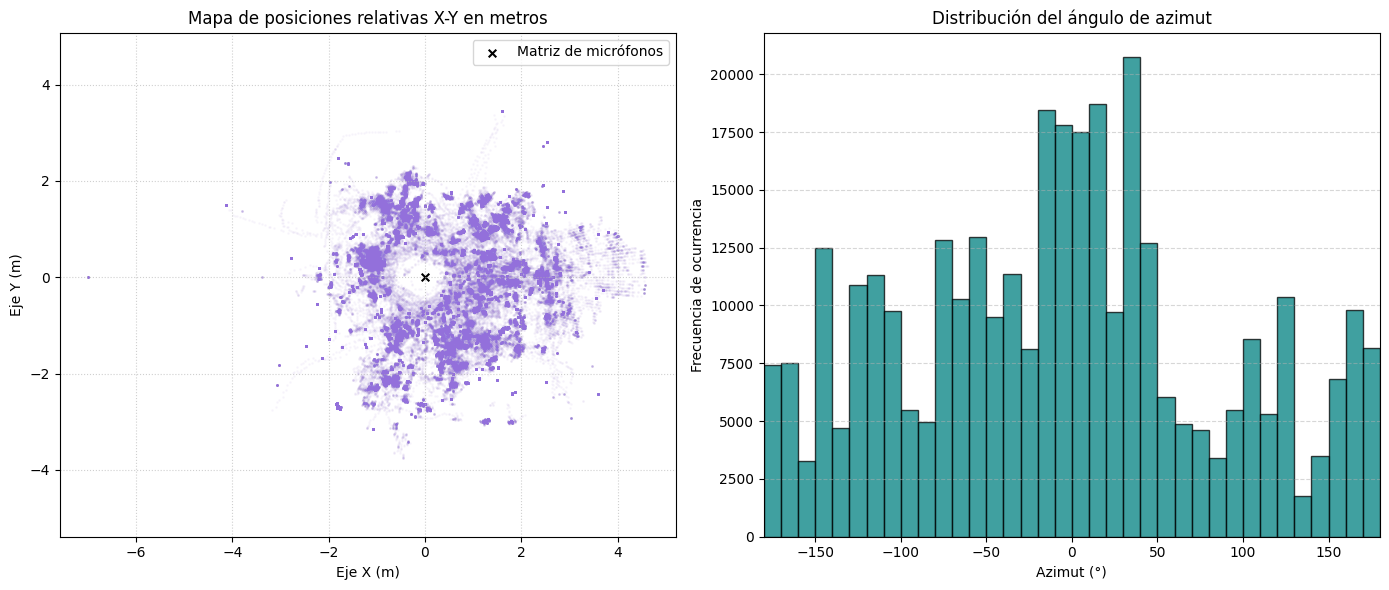

In [9]:

# ============================================================
# 3. DISTRIBUCIÓN ESPACIAL CORREGIDA
# ============================================================

print("Calculando coordenadas X-Y reales a partir de azimut, elevación y distancia...")

x_coords, y_coords, z_coords = [], [], []
azimuths, elevations, dists_for_check = [], [], []

for path in csv_files:
    try:
        df = read_metadata_csv(path)
        parsed = extract_spatial_from_df(df)
        if parsed is None:
            continue

        x, y, z, azimuth, elevation, distance = parsed

        x_coords.extend(pd.Series(x).dropna().astype(float).tolist())
        y_coords.extend(pd.Series(y).dropna().astype(float).tolist())
        z_coords.extend(pd.Series(z).dropna().astype(float).tolist())
        azimuths.extend(pd.Series(azimuth).dropna().astype(float).tolist())
        elevations.extend(pd.Series(elevation).dropna().astype(float).tolist())
        dists_for_check.extend(pd.Series(distance).dropna().astype(float).tolist())

    except Exception as e:
        print(f"Error procesando coordenadas en {path.name}: {e}")

x_coords = np.array(x_coords, dtype=float)
y_coords = np.array(y_coords, dtype=float)
z_coords = np.array(z_coords, dtype=float)
azimuths = np.array(azimuths, dtype=float)
elevations = np.array(elevations, dtype=float)
dists_for_check = np.array(dists_for_check, dtype=float)

valid = (
    np.isfinite(x_coords) & np.isfinite(y_coords) &
    np.isfinite(z_coords) & np.isfinite(azimuths) &
    np.isfinite(elevations) & np.isfinite(dists_for_check)
)

x_coords = x_coords[valid]
y_coords = y_coords[valid]
z_coords = z_coords[valid]
azimuths = azimuths[valid]
elevations = elevations[valid]
dists_for_check = dists_for_check[valid]

print(f"Total de puntos espaciales analizados: {len(x_coords)}")

if len(x_coords) == 0:
    raise RuntimeError("No se han extraído coordenadas espaciales. Revisa METADATA_FORMAT y los CSV.")

# Comprobación de coherencia: sqrt(x^2+y^2+z^2) debe coincidir con la distancia si usamos formato esférico.
dist_reconstructed = np.sqrt(x_coords**2 + y_coords**2 + z_coords**2)
check_df = pd.DataFrame([{
    "distancia_original_media_m": np.mean(dists_for_check),
    "distancia_reconstruida_media_m": np.mean(dist_reconstructed),
    "error_abs_medio_m": np.mean(np.abs(dists_for_check - dist_reconstructed)),
    "x_min_m": np.min(x_coords),
    "x_max_m": np.max(x_coords),
    "y_min_m": np.min(y_coords),
    "y_max_m": np.max(y_coords),
}])

print("\n--- Comprobación de coordenadas ---")
display(check_df)
check_df.to_csv(Path(output_dir) / "resumen_coordenadas_xy.csv", index=False, encoding="utf-8-sig")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Vista X-Y en metros reales
ax1.scatter(x_coords, y_coords, alpha=0.04, color="mediumpurple", s=1)
ax1.scatter([0], [0], color="black", s=30, marker="x", label="Matriz de micrófonos")
ax1.set_title("Mapa de posiciones relativas X-Y en metros")
ax1.set_xlabel("Eje X (m)")
ax1.set_ylabel("Eje Y (m)")
ax1.grid(True, linestyle=":", alpha=0.6)
ax1.axis("equal")
ax1.legend(loc="upper right")

# Histograma de azimut
ax2.hist(azimuths, bins=36, color="teal", edgecolor="black", alpha=0.75)
ax2.set_title("Distribución del ángulo de azimut")
ax2.set_xlabel("Azimut (°)")
ax2.set_ylabel("Frecuencia de ocurrencia")
ax2.set_xlim(-180, 180)
ax2.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig(Path(output_dir) / "analisis_preliminar_espacial_doa.png", dpi=300)
plt.show()


Calculando solapamiento de eventos por frame...

--- Estadísticas de polifonía ---


,Fuentes_simultaneas,Num_frames,Porcentaje
3,1,140274,62.274529
0,2,62536,27.762807
1,3,18257,8.105180
2,4,3764,1.671025
4,5,416,0.184683
5,6,4,0.001776


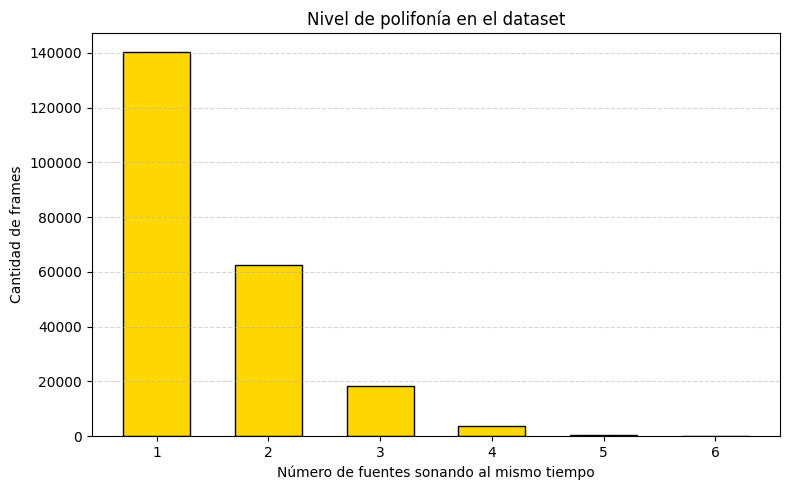

In [10]:

# ============================================================
# 4. NIVEL DE POLIFONÍA
# ============================================================

print("Calculando solapamiento de eventos por frame...")

polyphony_per_frame = []

for path in csv_files:
    try:
        df = read_metadata_csv(path)
        if df.empty or df.shape[1] < 1:
            continue

        # Columna 0: frame
        counts = df.groupby(0).size().tolist()
        polyphony_per_frame.extend(counts)

    except Exception as e:
        print(f"Error procesando polifonía en {path.name}: {e}")

if not polyphony_per_frame:
    raise RuntimeError("No se ha podido calcular polifonía. Revisa los metadatos.")

poly_counts = Counter(polyphony_per_frame)
poly_df = pd.DataFrame([
    {"Fuentes_simultaneas": k, "Num_frames": v}
    for k, v in poly_counts.items()
]).sort_values(by="Fuentes_simultaneas")

poly_df["Porcentaje"] = 100 * poly_df["Num_frames"] / poly_df["Num_frames"].sum()

print("\n--- Estadísticas de polifonía ---")
display(poly_df)

poly_df.to_csv(Path(output_dir) / "resumen_polifonia.csv", index=False, encoding="utf-8-sig")

plt.figure(figsize=(8, 5))
plt.bar(
    poly_df["Fuentes_simultaneas"].astype(str),
    poly_df["Num_frames"],
    color="gold",
    edgecolor="black",
    width=0.6
)
plt.title("Nivel de polifonía en el dataset")
plt.xlabel("Número de fuentes sonando al mismo tiempo")
plt.ylabel("Cantidad de frames")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()

plt.savefig(Path(output_dir) / "analisis_preliminar_polifonia.png", dpi=300)
plt.show()
